Dataset Shape: (1000, 10)

First 5 Rows
   Resume_ID         Name                                        Skills  \
0          1  Candidate_1  Machine Learning, C++, Python, Data Analysis   
1          2  Candidate_2     Java, Deep Learning, AWS, Cloud Computing   
2          3  Candidate_3                         Data Analysis, Python   
3          4  Candidate_4   Cloud Computing, SQL, AWS, Machine Learning   
4          5  Candidate_5               Power BI, C++, Machine Learning   

   Experience_Years Education          Certifications           Job_Role  \
0                 6      B.Sc  TensorFlow Certificate  Software Engineer   
1                10       MBA   Google Data Analytics        ML Engineer   
2                 6    B.Tech                    None       Data Analyst   
3                 6    B.Tech           AWS Certified  Software Engineer   
4                 7      M.Sc           AWS Certified     Cloud Engineer   

   Salary_Expectation  Projects_Count  Recruiter_Dec

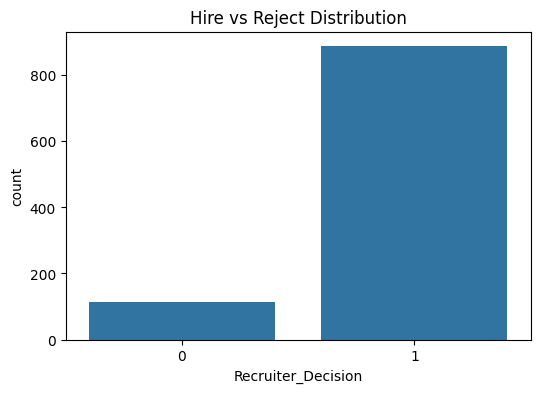

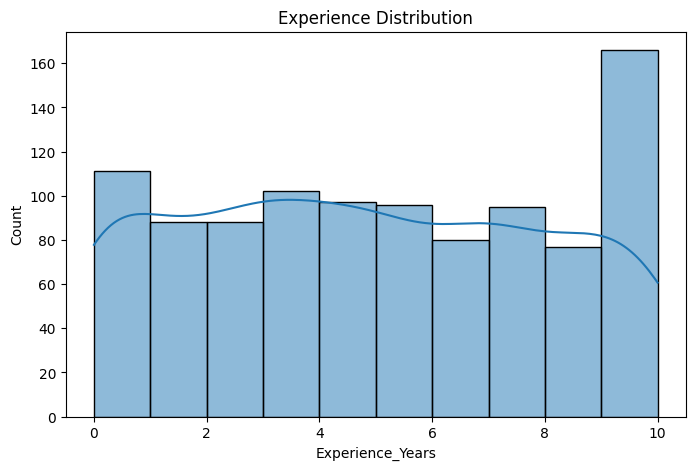

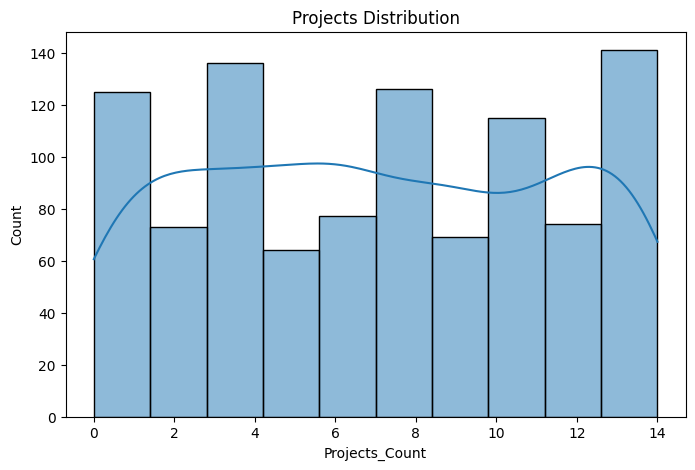

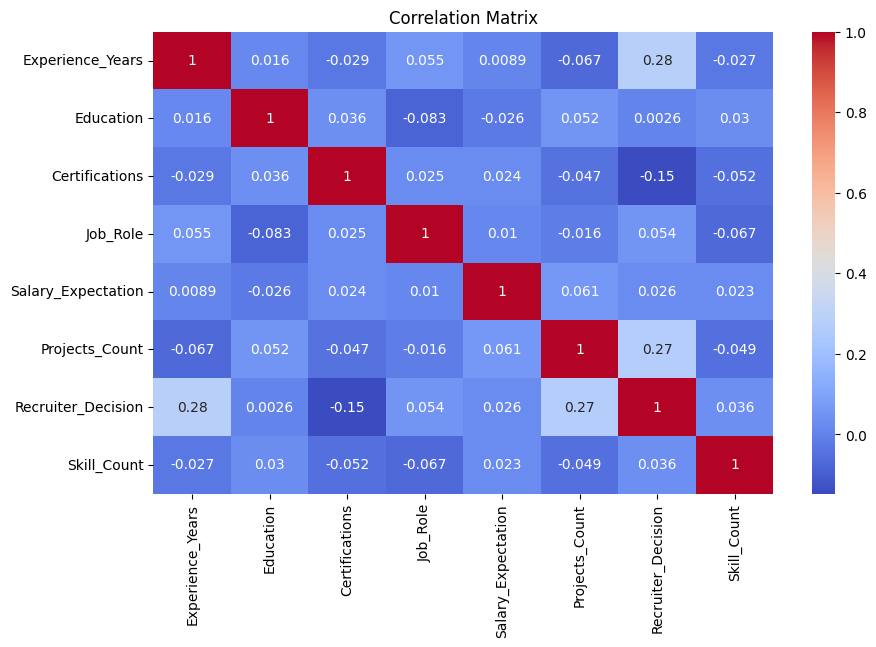


MODEL PERFORMANCE
Accuracy : 0.885
Precision: 0.9176
Recall   : 0.9543
F1 Score : 0.9356

Classification Report
              precision    recall  f1-score   support

           0       0.56      0.40      0.47        25
           1       0.92      0.95      0.94       175

    accuracy                           0.89       200
   macro avg       0.74      0.68      0.70       200
weighted avg       0.87      0.89      0.88       200



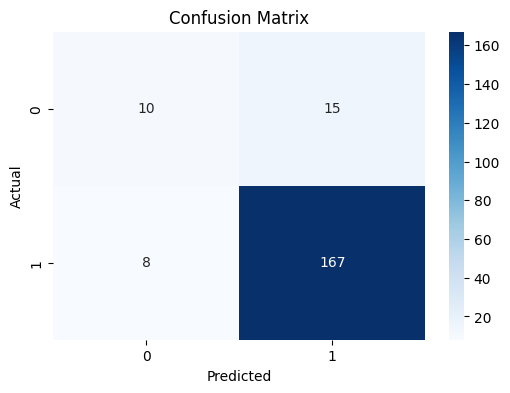


Feature Importance
              Feature  Importance
5      Projects_Count    0.271719
0    Experience_Years    0.245244
2      Certifications    0.160707
4  Salary_Expectation    0.149440
3            Job_Role    0.063340
1           Education    0.061268
6         Skill_Count    0.048283


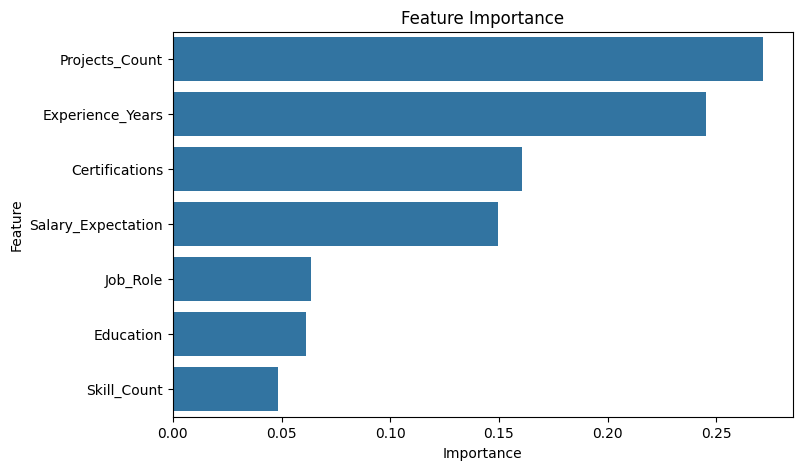


Candidate Prediction: HIRED


c:\Users\Vicky\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# ==========================================================
# AI-Based Hiring Prediction System
# End-to-End Machine Learning Project
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier



np.random.seed(42)

skills_list = [
    "Python", "Java", "C++", "Machine Learning",
    "Deep Learning", "SQL", "Power BI",
    "Data Analysis", "AWS", "Cloud Computing"
]

education_list = [
    "B.Tech",
    "M.Tech",
    "B.Sc",
    "M.Sc",
    "MBA"
]

certification_list = [
    "None",
    "AWS Certified",
    "Google Data Analytics",
    "Microsoft Azure",
    "TensorFlow Certificate"
]

job_roles = [
    "Data Scientist",
    "ML Engineer",
    "Software Engineer",
    "Data Analyst",
    "Cloud Engineer"
]

data = []

for i in range(1000):

    experience = np.random.randint(0, 11)

    education = random.choice(education_list)

    certification = random.choice(certification_list)

    role = random.choice(job_roles)

    projects = np.random.randint(0, 15)

    salary = np.random.randint(30000, 120000)

    skills = ", ".join(random.sample(skills_list, random.randint(2, 5)))

    # Hiring Logic
    hire_score = 0

    if experience >= 3:
        hire_score += 1

    if projects >= 5:
        hire_score += 1

    if certification != "None":
        hire_score += 1

    if "Python" in skills:
        hire_score += 1

    decision = 1 if hire_score >= 2 else 0

    data.append([
        i + 1,
        f"Candidate_{i+1}",
        skills,
        experience,
        education,
        certification,
        role,
        salary,
        projects,
        decision
    ])

df = pd.DataFrame(data, columns=[
    "Resume_ID",
    "Name",
    "Skills",
    "Experience_Years",
    "Education",
    "Certifications",
    "Job_Role",
    "Salary_Expectation",
    "Projects_Count",
    "Recruiter_Decision"
])


df.to_csv("Hiring_Dataset.csv", index=False)

print("Dataset Shape:", df.shape)



print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())


print("\nMissing Values")
print(df.isnull().sum())



plt.figure(figsize=(6,4))
sns.countplot(x='Recruiter_Decision', data=df)
plt.title("Hire vs Reject Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Experience_Years'], bins=10, kde=True)
plt.title("Experience Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Projects_Count'], bins=10, kde=True)
plt.title("Projects Distribution")
plt.show()


le_edu = LabelEncoder()
le_cert = LabelEncoder()
le_role = LabelEncoder()

df["Education"] = le_edu.fit_transform(df["Education"])
df["Certifications"] = le_cert.fit_transform(df["Certifications"])
df["Job_Role"] = le_role.fit_transform(df["Job_Role"])


df["Skill_Count"] = df["Skills"].apply(lambda x: len(x.split(",")))


df = df.drop(["Resume_ID", "Name", "Skills"], axis=1)


plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


X = df.drop("Recruiter_Decision", axis=1)

y = df["Recruiter_Decision"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)



y_pred = model.predict(X_test)



accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()



sample = [[
    5,      # Experience Years
    2,      # Education Encoded
    1,      # Certification Encoded
    0,      # Job Role Encoded
    80000,  # Salary Expectation
    8,      # Projects
    4       # Skill Count
]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("\nCandidate Prediction: HIRED")
else:
    print("\nCandidate Prediction: REJECTED")